In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

In [3]:
import pandas as pd


df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

In [4]:
import pickle
from correct_systematic_error import correct_systematic_error
from itertools import product
import scipy.stats as stats


seeds = np.arange(50)
nbins_list = [2**i for i in range(7)]
experiment_name = "CR_fvt_training_v2"
bins_mode = "quantile"
n_3b = 100_0000

corrections_dict = {}
hists_dict = {}

pull_arrays_dict = {}
for slope_min, slope_max, intercept_min, intercept_max in [
    (-0.05, 0.05, -0.0125, 0.0125),
    (-0.1, 0.1, -0.025, 0.025),
    (-0.2, 0.2, -0.05, 0.05),
    (0.0, 0.0, -0.1, 0.1),
    (-0.2, 0.2, -0.1, 0.1),
    (-2, 2, -1, 1),
    # (0.0, 0.0, -np.inf, np.inf),
]:
    print(f"slope_min = {slope_min}, slope_max = {slope_max}, intercept_min = {intercept_min}, intercept_max = {intercept_max}")
    for signal_ratio in [0.0, 0.01, 0.02]:
        for seed in tqdm.tqdm(seeds):
            hparam_filter = {
                "experiment_name": experiment_name,
                "dataset": lambda x: all([x["seed"] == seed, 
                                    x["n_3b"] == n_3b, 
                                    x["signal_ratio"] == signal_ratio]),
                "aux_info_step": 3, 
                "model": "FvTClassifier"
            }
            hashes = TrainingInfo.find(hparam_filter)
            assert len(hashes) == 1
            
            hash = hashes[0]
            corrections, hists = correct_systematic_error(hash, nbins_list, bins_mode, 
                                    correction_split_ratio=0.2,
                                    correction_split_seed=0,
                                    intercept_min=intercept_min,
                                    intercept_max=intercept_max,
                                    slope_min=slope_min,
                                    slope_max=slope_max,
                                    raw_df_list=raw_df_list)
            
            corrections_dict[(signal_ratio, seed)] = corrections
            hists_dict[(signal_ratio, seed)] = hists
            
    pull_arrays = {(signal_ratio, nbins): [] for signal_ratio, nbins in product([0.0, 0.01, 0.02], nbins_list)}

    for signal_ratio, seed in tqdm.tqdm(product([0.0, 0.01, 0.02], seeds)):
        for nbins in nbins_list:
            hist_3b_corrected = hists_dict[(signal_ratio, seed)][nbins]["3b_corrected"]
            hist_3b_corrected_sq = hists_dict[(signal_ratio, seed)][nbins]["3b_corrected_sq"]
            hist_4b = hists_dict[(signal_ratio, seed)][nbins]["4b"]
            hist_4b_sq = hists_dict[(signal_ratio, seed)][nbins]["4b_sq"]
            hist_diff = hist_4b - hist_3b_corrected
            hist_var = hist_3b_corrected_sq + hist_4b_sq
            pull = hist_diff / np.sqrt(hist_var)
            pull_arrays[(signal_ratio, nbins)].append(pull)
            
    pull_arrays = {k: np.array(v) for k, v in pull_arrays.items()}
    pull_arrays_dict[(slope_min, slope_max, intercept_min, intercept_max)] = pull_arrays

    # sig_level = 0.05
    # z_rej = stats.norm.ppf(1 - sig_level / 2)
    # fig, ax = plt.subplots(nrows=len(nbins_list), ncols=3, figsize=(15, 40))
    # fig.supxlabel("SR bin")
    # fig.supylabel("Rejection rate")
    # for a in ax.flatten():
    #     a.set_xlim(0, 1)
    #     a.set_ylim(0, 0.6)
    #     a.axhline(sig_level, color="red", linestyle="--", linewidth=0.5)
    # for i, (nbins, signal_ratio) in enumerate(product(nbins_list, [0.0, 0.01, 0.02])):
    #     current_ax = ax[i // 3, i % 3]
    #     current_ax.set_title(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
    #     current_ax.plot((np.arange(nbins) + 1 / 2) / nbins, np.mean(np.abs(pull_arrays[(signal_ratio, nbins)]) > z_rej, axis=0), "o-")
    #     for pos in np.arange(nbins + 1) / nbins:
    #         current_ax.axvline(pos, color="black", linestyle="--", linewidth=0.5)
    # plt.tight_layout()
    # plt.show()

with open("./data/tmp/pull_arrays_dict.pkl", "wb") as f:
    pickle.dump(pull_arrays_dict, f)

slope_min = -0.05, slope_max = 0.05, intercept_min = -0.0125, intercept_max = 0.0125


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [02:04<00:00,  2.49s/it]
150it [00:00, 22523.38it/s]


slope_min = -0.1, slope_max = 0.1, intercept_min = -0.025, intercept_max = 0.025


100%|██████████| 50/50 [02:03<00:00,  2.48s/it]
150it [00:00, 24542.45it/s]


...

100%|██████████| 50/50 [02:02<00:00,  2.45s/it]
150it [00:00, 24296.96it/s]


slope_min = -0.2, slope_max = 0.2, intercept_min = -0.1, intercept_max = 0.1


100%|██████████| 50/50 [02:03<00:00,  2.47s/it]
150it [00:00, 24436.63it/s]


slope_min = -2, slope_max = 2, intercept_min = -1, intercept_max = 1


100%|██████████| 50/50 [02:02<00:00,  2.45s/it]
150it [00:00, 24770.49it/s]


In [4]:
import pickle
pull_arrays_dict = pickle.load(open("./data/tmp/pull_arrays_dict.pkl", "rb"))

In [5]:
sig_level = 0.05

for (slope_min, slope_max, intercept_min, intercept_max), pull_arrays in pull_arrays_dict.items():
    print(f"slope_min = {slope_min}, slope_max = {slope_max}, intercept_min = {intercept_min}, intercept_max = {intercept_max}")
    for nbins, signal_ratio in product(nbins_list, [0.0, 0.01, 0.02]):
        print(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
        chi2_stat = np.sqrt(np.mean(pull_arrays[(signal_ratio, nbins)]**2, axis=1))
        z_rej = stats.chi2.ppf(1 - sig_level, df=nbins)
        z_rej = np.sqrt(z_rej / nbins)
        print(np.mean(chi2_stat > z_rej))

slope_min = -0.05, slope_max = 0.05, intercept_min = -0.0125, intercept_max = 0.0125


NameError: name 'product' is not defined

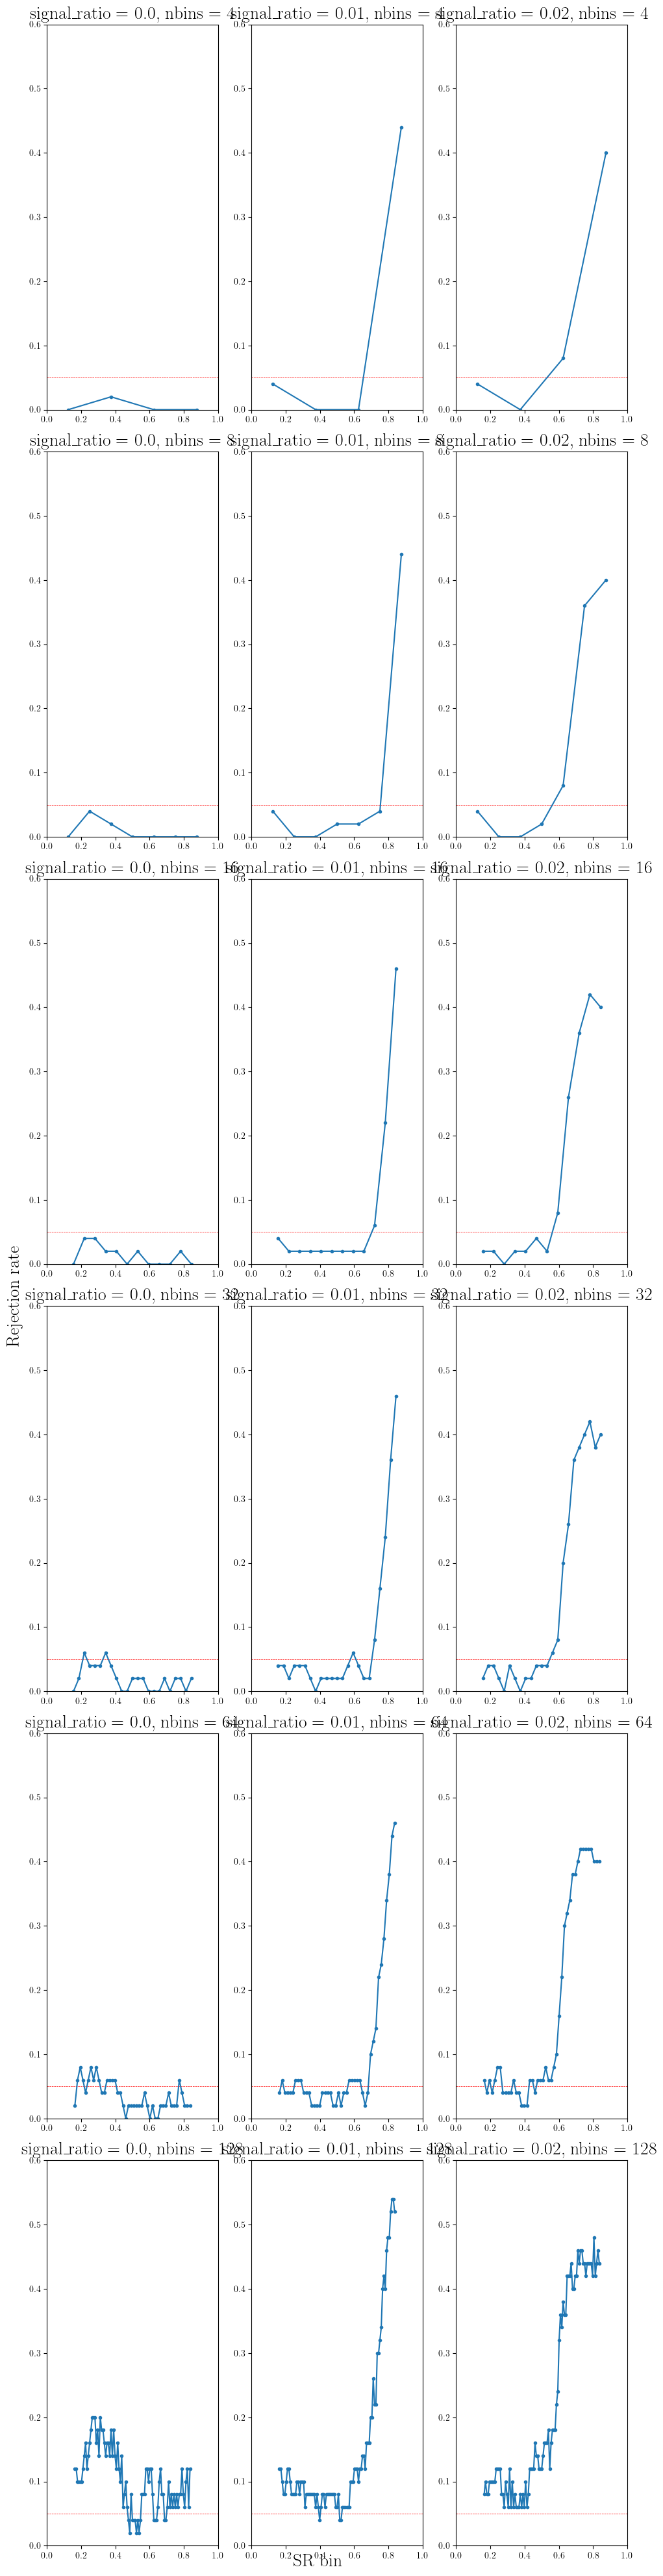

In [25]:
nbins_list = [2**i for i in range(2, 8)]
sig_level = 0.05
z_rej = stats.norm.ppf(1 - sig_level / 2)
window_frac = 1/3

pull_arrays = {(signal_ratio, nbins): [] for signal_ratio, nbins in product([0.0, 0.01, 0.02], nbins_list)}

for k, v in hists_dict.items():
    signal_ratio, seed = k
    for nbins in nbins_list:
        window_size = int(nbins * window_frac)
        
        hist_3b_corrected = v[nbins]["3b_corrected"]
        hist_3b_corrected_sq = v[nbins]["3b_corrected_sq"]
        hist_4b = v[nbins]["4b"]
        hist_4b_sq = v[nbins]["4b_sq"]
        
        hist_3b_corrected_window = np.convolve(hist_3b_corrected, np.ones((window_size,)), mode="valid")
        hist_3b_corrected_sq_window = np.convolve(hist_3b_corrected_sq, np.ones((window_size,)), mode="valid")
        hist_4b_window = np.convolve(hist_4b, np.ones((window_size,)), mode="valid")
        hist_4b_sq_window = np.convolve(hist_4b_sq, np.ones((window_size,)), mode="valid")
        
        hist_diff = hist_4b_window - hist_3b_corrected_window
        hist_var = hist_3b_corrected_sq_window + hist_4b_sq_window
        pull = hist_diff / np.sqrt(hist_var)
        pull_arrays[(signal_ratio, nbins)].append(pull)
        
pull_arrays = {k: np.array(v) for k, v in pull_arrays.items()}
    
fig, ax = plt.subplots(len(nbins_list), 3, figsize=(10, 40))
fig.supxlabel("SR bin")
fig.supylabel("Rejection rate")
for a in ax.flatten():
    a.set_xlim(0, 1)
    a.set_ylim(0, 0.6)
    a.axhline(sig_level, color="red", linestyle="--", linewidth=0.5)
for i, (nbins, signal_ratio) in enumerate(product(nbins_list, [0.0, 0.01, 0.02])):
    window_size = int(nbins * window_frac)
    current_ax = ax[i // 3, i % 3]
    current_ax.set_title(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
    current_ax.plot((np.arange(nbins - window_size + 1) + window_size / 2) / nbins, 
                   np.mean(pull_arrays[(signal_ratio, nbins)] > z_rej, axis=0), "o-")
    
plt.tight_layout()
plt.show()

In [26]:
nbins = 2**7
print(f"signal_ratio = 0.0")
print([corrections_dict[(0.0, seed)][nbins] for seed in seeds])
print(f"signal_ratio = 0.01")
print([corrections_dict[(0.01, seed)][nbins] for seed in seeds])
print(f"signal_ratio = 0.02")
print([corrections_dict[(0.02, seed)][nbins] for seed in seeds])

signal_ratio = 0.0
[[(0.009342527118265265, 0.0)], [(-0.010804614882556698, 0.0)], [(-0.02280680450753551, 0.0)], [(0.01817392708502654, 0.0)], [(0.02038865625444383, 0.0)], [(0.0043549652622329165, 0.0)], [(0.01248771274150963, 0.0)], [(-0.05323800434115565, 0.0)], [(-0.03516724177131856, 0.0)], [(-0.018445198506939164, 0.0)], [(0.01651496698526214, 0.0)], [(-0.008363852400797034, 0.0)], [(-0.017553222545618148, 0.0)], [(-0.06617577453482472, 0.0)], [(-0.04118688499026702, 0.0)], [(0.019641978129422595, 0.0)], [(0.0016582031586875406, 0.0)], [(-0.002639452727527297, 0.0)], [(-0.039681566483197234, 0.0)], [(-0.047084700559681024, 0.0)], [(-0.06891356736448156, 0.0)], [(0.0007336984791803952, 0.0)], [(0.0046162312610165375, 0.0)], [(-0.05738828140271788, 0.0)], [(-0.0011064011296505556, 0.0)], [(-0.0538652726673716, 0.0)], [(-0.010146509890647366, 0.0)], [(-0.04355317161074241, 0.0)], [(0.0014569060781733612, 0.0)], [(0.018429226476771903, 0.0)], [(-0.03293252936616434, 0.0)], [(-0.0309

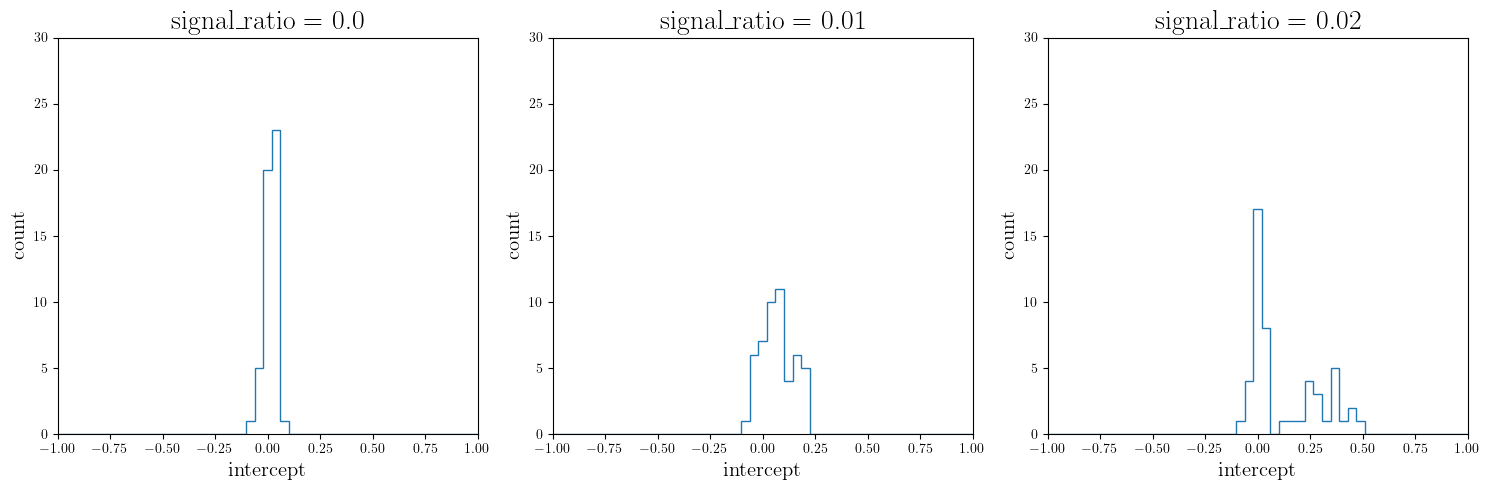

In [29]:
nbins = 2**2

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a in ax:
    a.set_xlabel("intercept")
    a.set_ylabel("count")
    a.set_xlim(-1, 1)
    a.set_ylim(0, 30)
for i, signal_ratio in enumerate([0.0, 0.01, 0.02]):
    ax[i].set_title(f"signal_ratio = {signal_ratio}")
    ax[i].hist([corrections_dict[(signal_ratio, seed)][nbins][0][0] for seed in seeds], histtype="step", 
               bins=np.linspace(-1, 1, 50))
plt.tight_layout()
plt.show()

In [ ]:
from correct_systematic_error import correct_systematic_error
from itertools import product
import scipy.stats as stats


seeds = np.arange(50)
nbins_list = [2**i for i in range(8)]
experiment_name = "CR_fvt_training_v2"
bins_mode = "quantile"
n_3b = 100_0000

slope_min = -0.2
slope_max = 0.2
intercept_min = -0.05
intercept_max = 0.05

corrections_dict = {}
hists_dict = {}

for signal_ratio in [0.0, 0.01, 0.02]:
    for seed in tqdm.tqdm(seeds):
        hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 3, 
            "model": "FvTClassifier"
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 1
        
        hash = hashes[0]
        corrections, hists = correct_systematic_error(hash, nbins_list, bins_mode, 
                                correction_split_ratio=0.2,
                                correction_split_seed=0,
                                intercept_min=intercept_min,
                                intercept_max=intercept_max,
                                slope_min=slope_min,
                                slope_max=slope_max,
                                raw_df_list=raw_df_list)
        
        corrections_dict[(signal_ratio, seed)] = corrections
        hists_dict[(signal_ratio, seed)] = hists
        
pull_arrays = {(signal_ratio, nbins): [] for signal_ratio, nbins in product([0.0, 0.01, 0.02], nbins_list)}

for signal_ratio, seed in tqdm.tqdm(product([0.0, 0.01, 0.02], seeds)):
    for nbins in nbins_list:
        hist_3b_corrected = hists_dict[(signal_ratio, seed)][nbins]["3b_corrected"]
        hist_3b_corrected_sq = hists_dict[(signal_ratio, seed)][nbins]["3b_corrected_sq"]
        hist_4b = hists_dict[(signal_ratio, seed)][nbins]["4b"]
        hist_4b_sq = hists_dict[(signal_ratio, seed)][nbins]["4b_sq"]
        hist_diff = hist_4b - hist_3b_corrected
        hist_var = hist_3b_corrected_sq + hist_4b_sq
        pull = hist_diff / np.sqrt(hist_var)
        pull_arrays[(signal_ratio, nbins)].append(pull)
        
pull_arrays = {k: np.array(v) for k, v in pull_arrays.items()}

sig_level = 0.05
z_rej = stats.norm.ppf(1 - sig_level / 2)
fig, ax = plt.subplots(nrows=len(nbins_list), ncols=3, figsize=(15, 40))
fig.supxlabel("SR bin")
fig.supylabel("Rejection rate")
for a in ax.flatten():
    a.set_xlim(0, 1)
    a.set_ylim(0, 0.6)
    a.axhline(sig_level, color="red", linestyle="--", linewidth=0.5)
for i, (nbins, signal_ratio) in enumerate(product(nbins_list, [0.0, 0.01, 0.02])):
    current_ax = ax[i // 3, i % 3]
    current_ax.set_title(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
    current_ax.plot((np.arange(nbins) + 1 / 2) / nbins, np.mean(pull_arrays[(signal_ratio, nbins)] > z_rej, axis=0), "o-")
    for pos in np.arange(nbins + 1) / nbins:
        current_ax.axvline(pos, color="black", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

150it [00:00, 26009.57it/s]


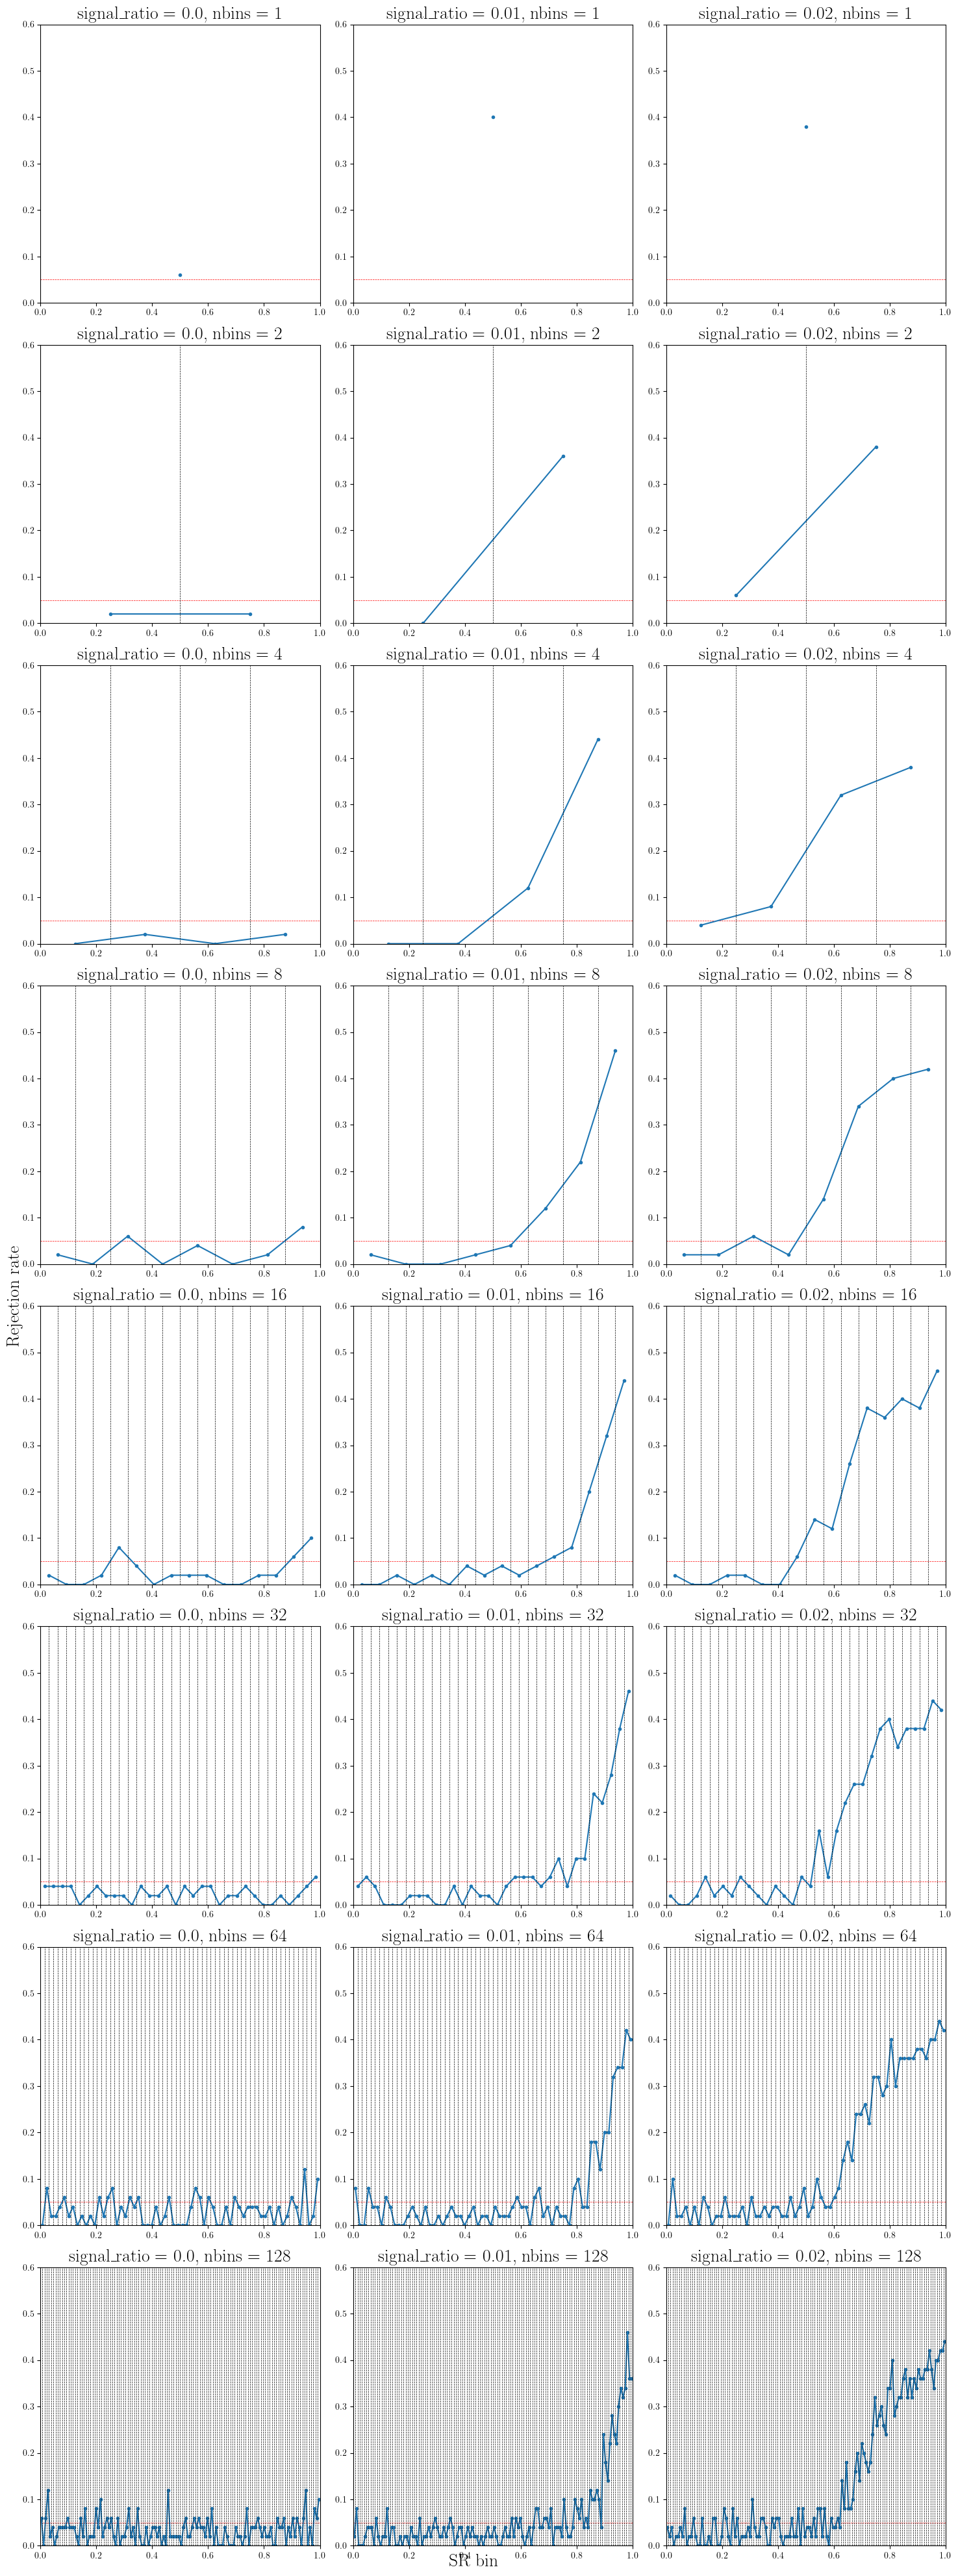

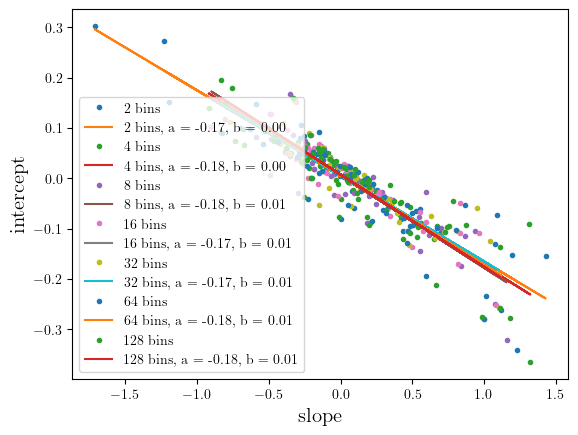

In [34]:
for nbins in nbins_list[1:]:
    intercepts, slopes = np.array(corrections[nbins]).T
    plt.plot(slopes, intercepts, "o", label=f"{nbins} bins")
    # linear fit
    # intercepts = a * slopes + b
    a, b = np.polyfit(slopes, intercepts, 1)
    plt.plot(slopes, a * slopes + b, label=f"{nbins} bins, a = {a:.2f}, b = {b:.2f}")

plt.legend()
plt.xlabel("slope")
plt.ylabel("intercept")
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

intercept = 0.02335345931351185, slope = 0


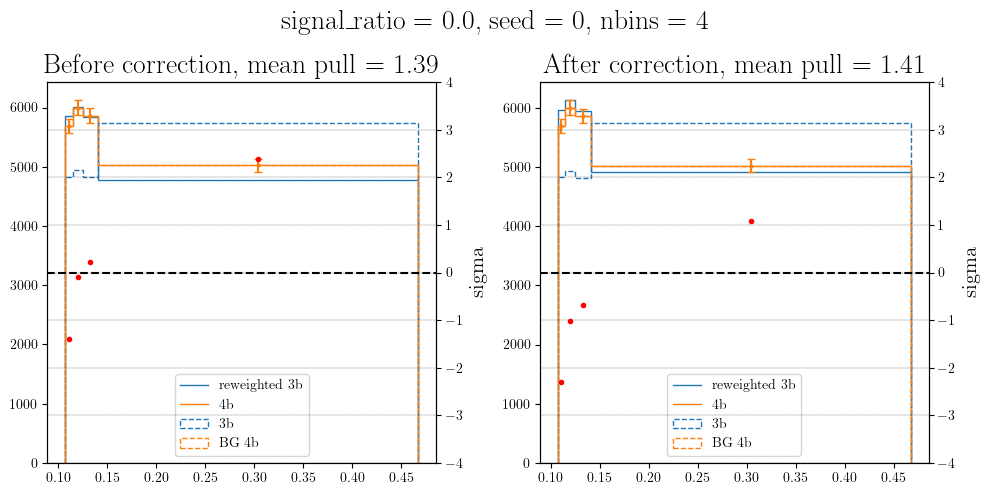

 10%|█         | 1/10 [00:08<01:13,  8.12s/it]

intercept = 0.01615268364548683, slope = 0


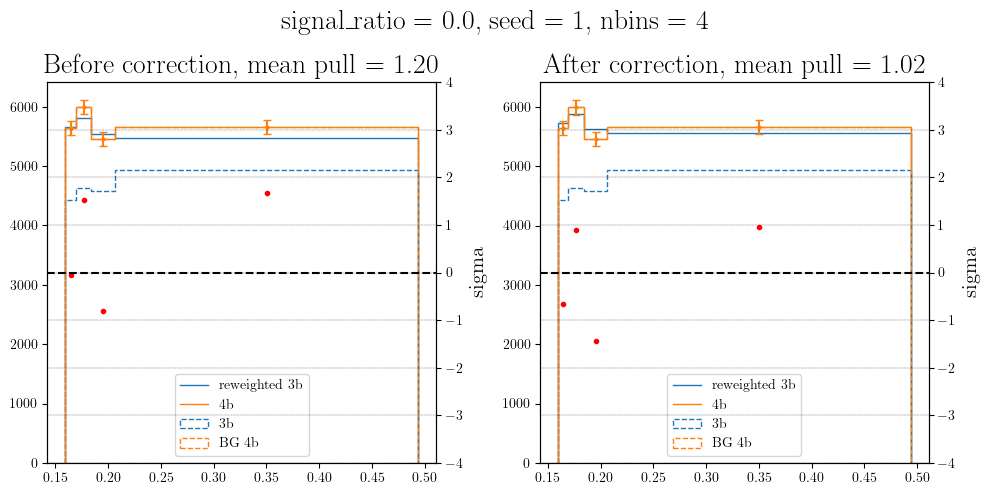

 20%|██        | 2/10 [00:15<00:59,  7.43s/it]

intercept = 0.004141730722039938, slope = 0


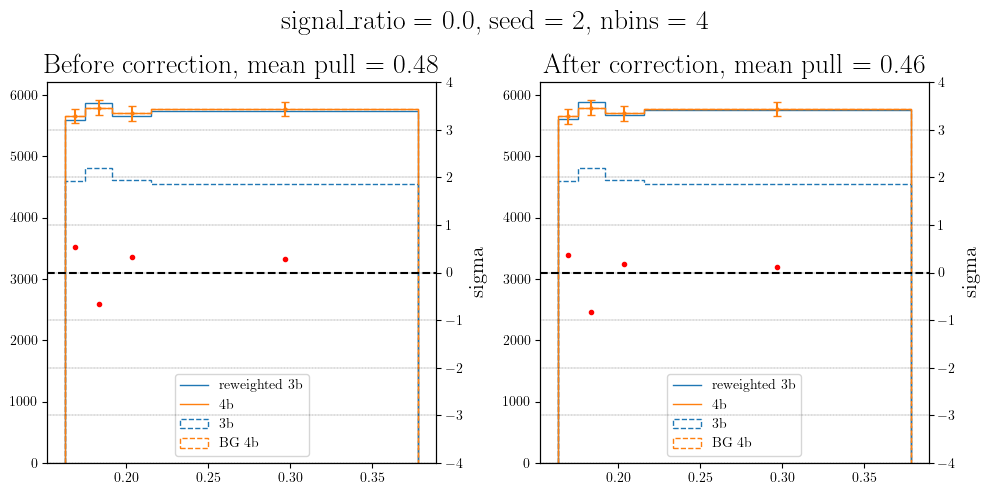

 30%|███       | 3/10 [00:22<00:50,  7.22s/it]

intercept = 0.04843132942914963, slope = 0


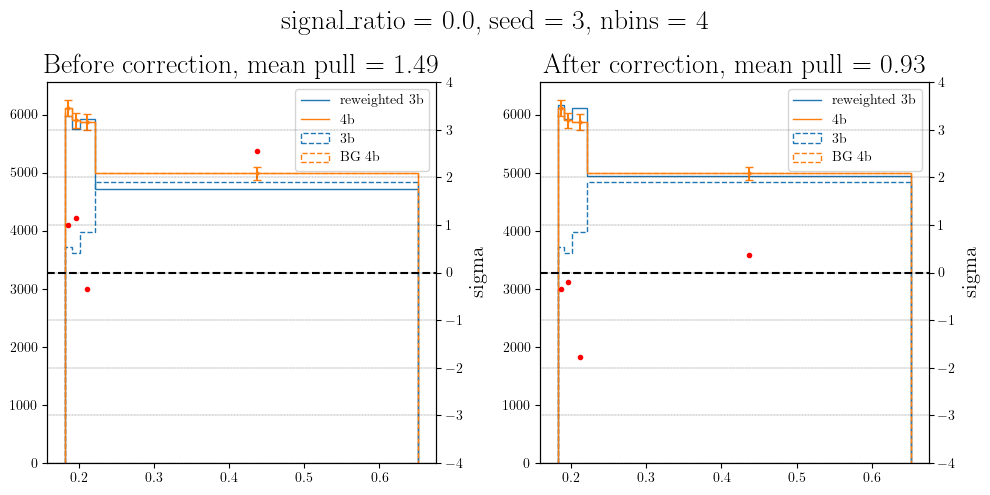

 40%|████      | 4/10 [00:29<00:42,  7.16s/it]

intercept = 0.047206584364175797, slope = 0


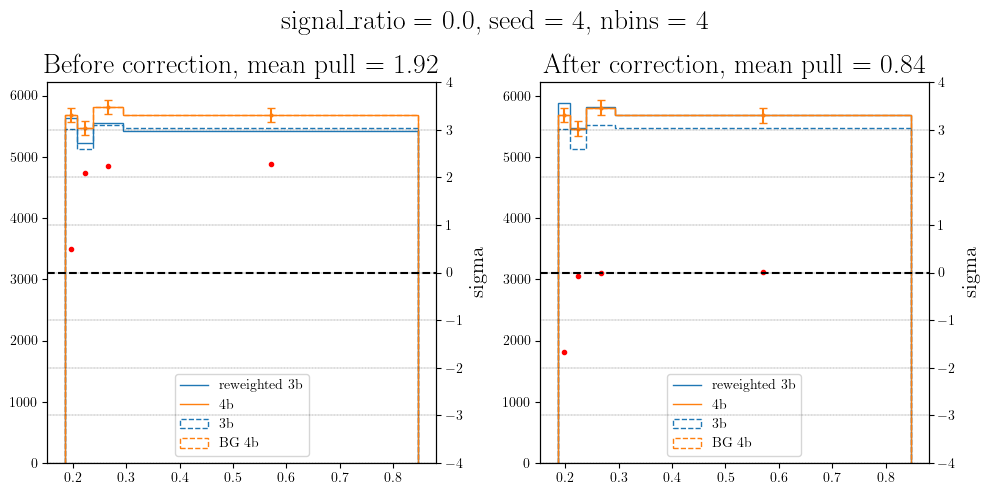

 50%|█████     | 5/10 [00:35<00:34,  6.96s/it]

intercept = 0.022613229230046272, slope = 0


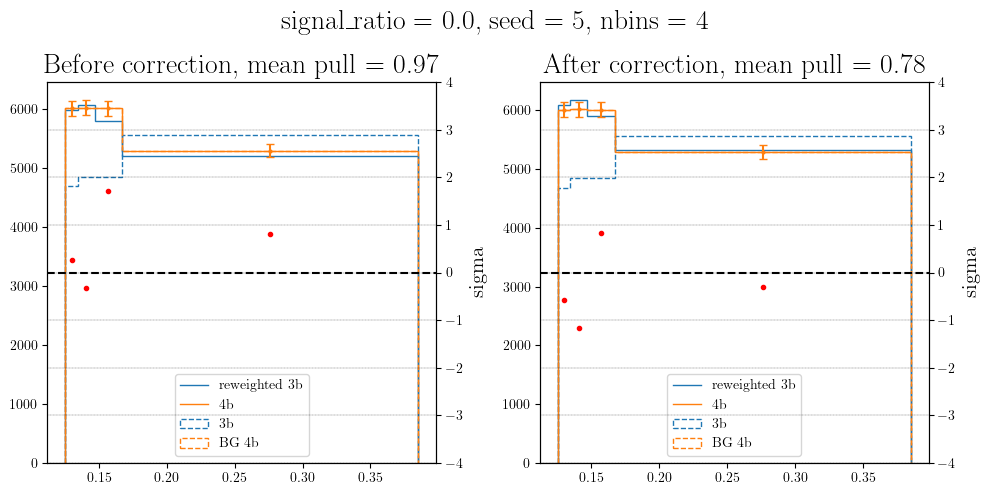

 60%|██████    | 6/10 [00:42<00:27,  6.79s/it]

intercept = 0.046505335718393326, slope = 0


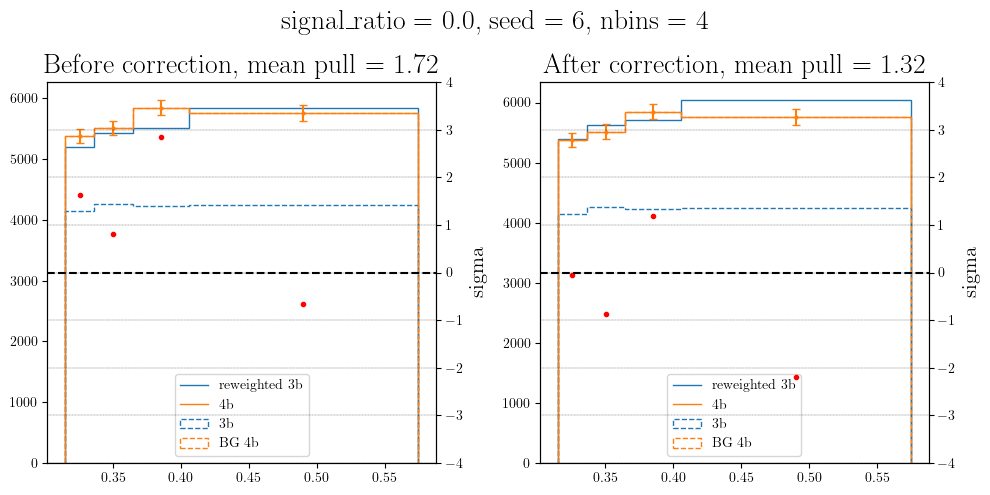

 70%|███████   | 7/10 [00:49<00:20,  6.86s/it]

intercept = -0.03775271400809288, slope = 0


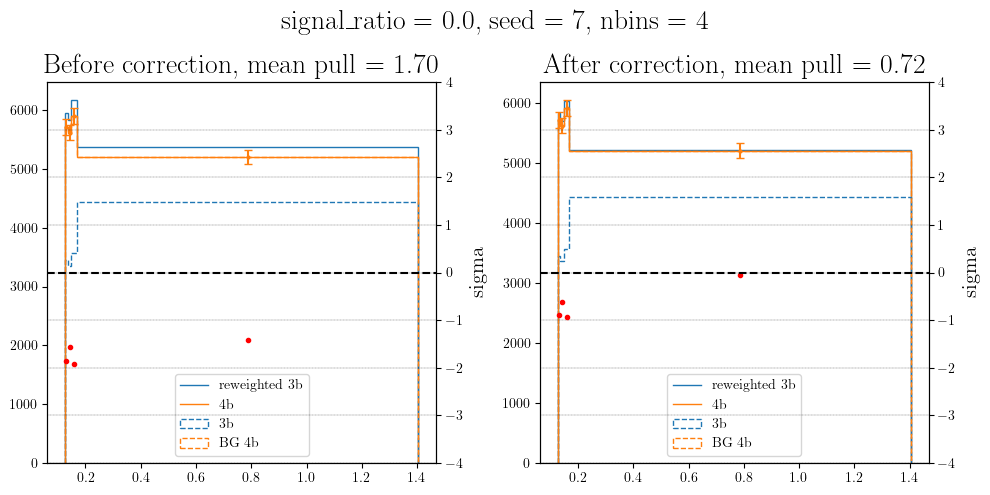

 80%|████████  | 8/10 [00:56<00:13,  6.89s/it]

intercept = -0.005583182442933321, slope = 0


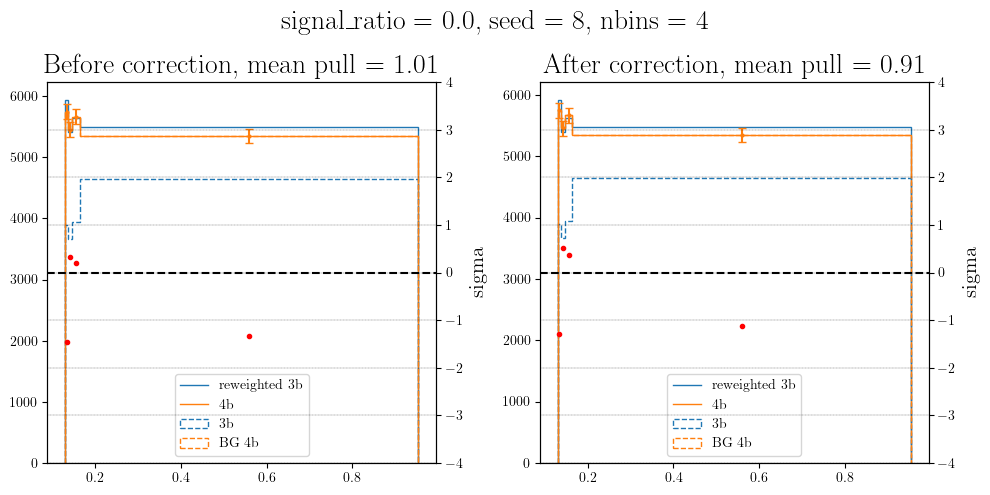

 90%|█████████ | 9/10 [01:02<00:06,  6.78s/it]

intercept = 0.0245070680975914, slope = 0


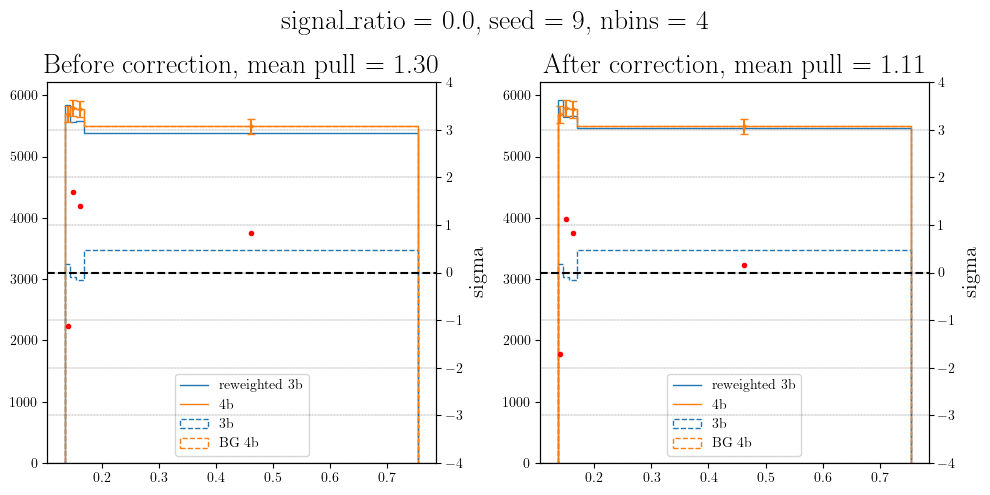

  0%|          | 0/10 [00:00<?, ?it/s]

intercept = 0.037135716527700424, slope = 0


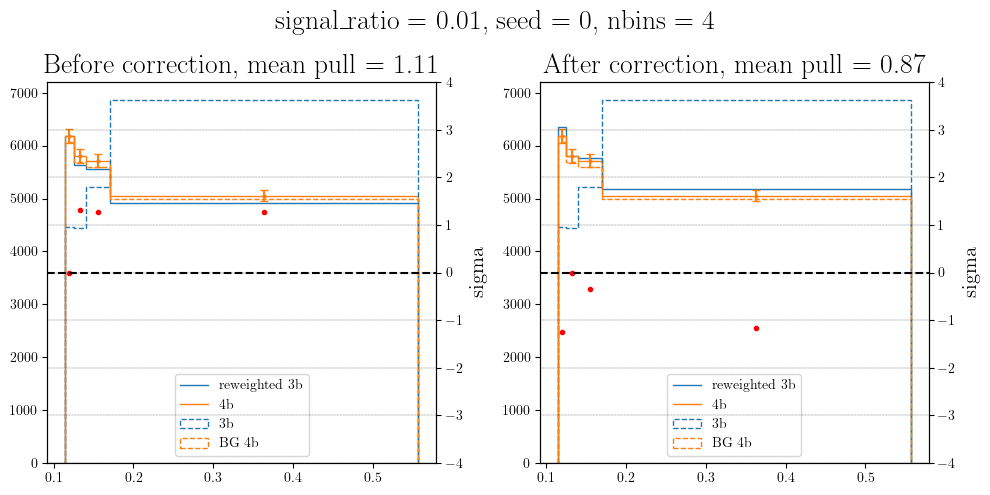

 10%|█         | 1/10 [00:06<00:59,  6.57s/it]

intercept = 0.030620036646723747, slope = 0


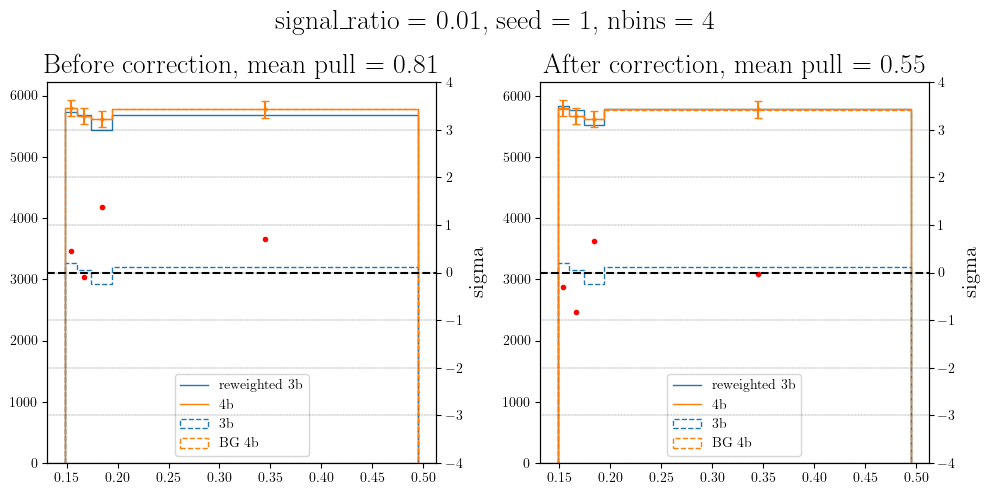

 20%|██        | 2/10 [00:13<00:54,  6.86s/it]

intercept = -0.035716719925403595, slope = 0


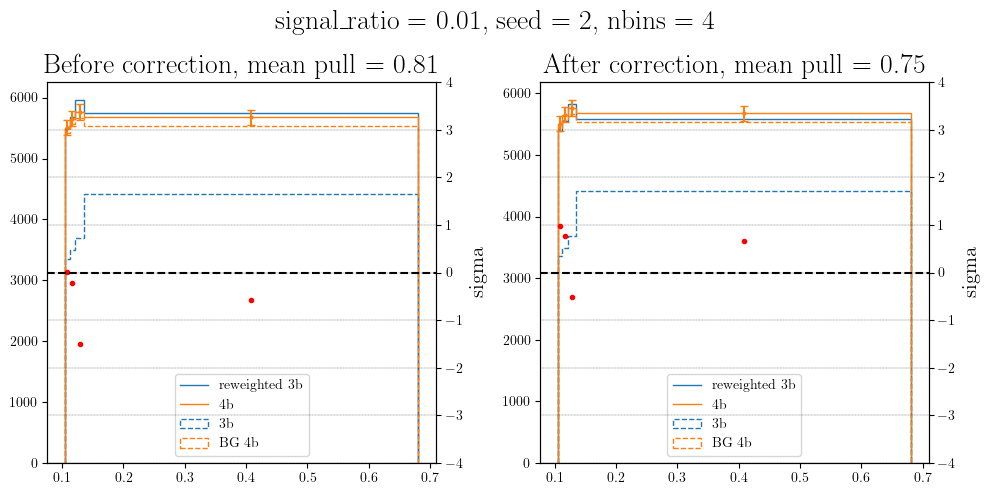

 30%|███       | 3/10 [00:20<00:48,  6.89s/it]

intercept = 0.1, slope = 0


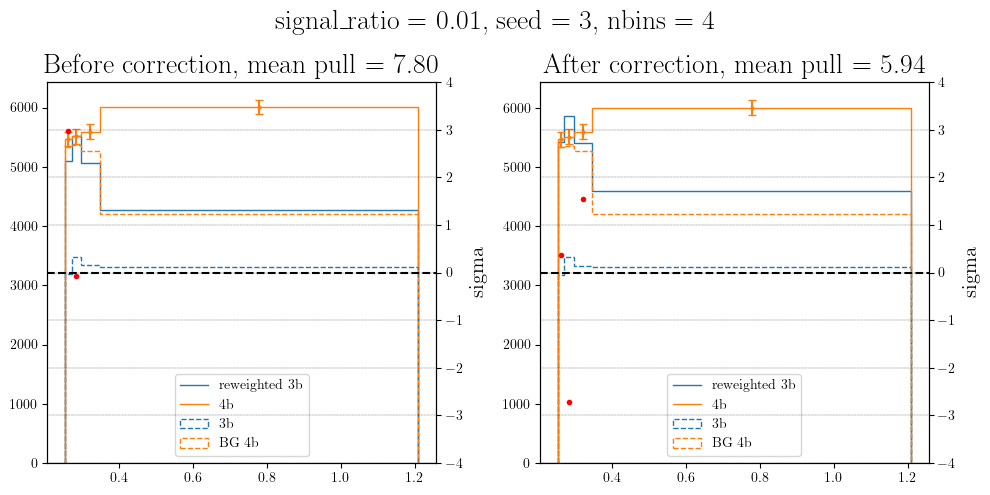

 40%|████      | 4/10 [00:27<00:41,  6.92s/it]

intercept = 0.1, slope = 0


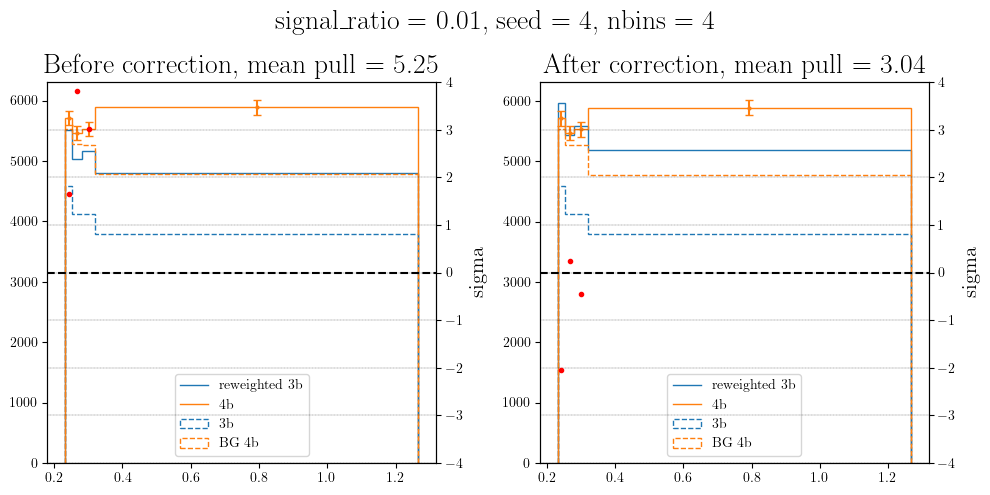

 50%|█████     | 5/10 [00:34<00:34,  6.99s/it]

intercept = 0.1, slope = 0


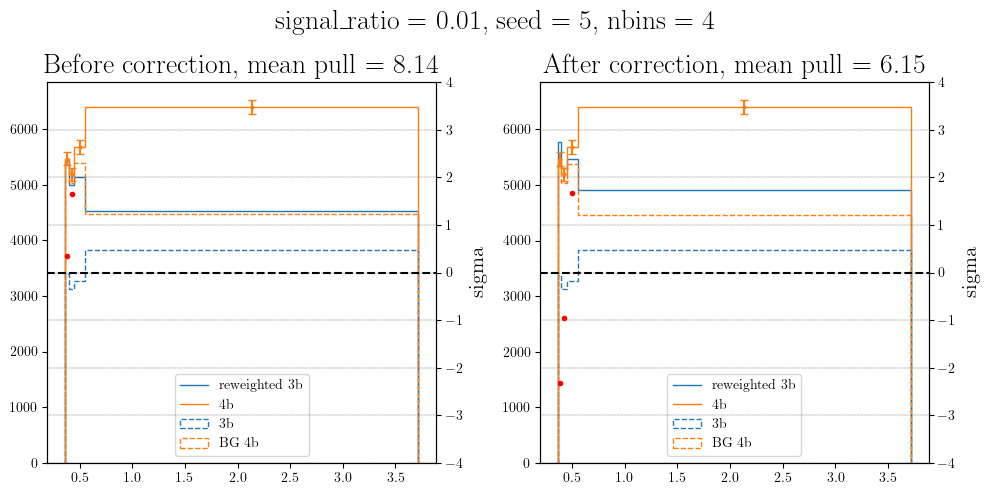

 60%|██████    | 6/10 [00:41<00:27,  6.99s/it]

intercept = 0.1, slope = 0


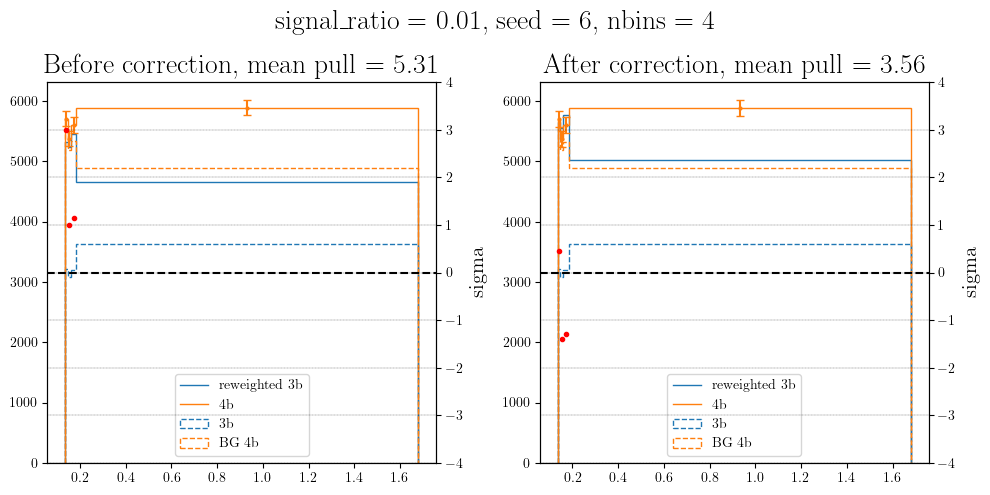

 70%|███████   | 7/10 [00:48<00:21,  7.02s/it]

intercept = -0.007281572557985783, slope = 0


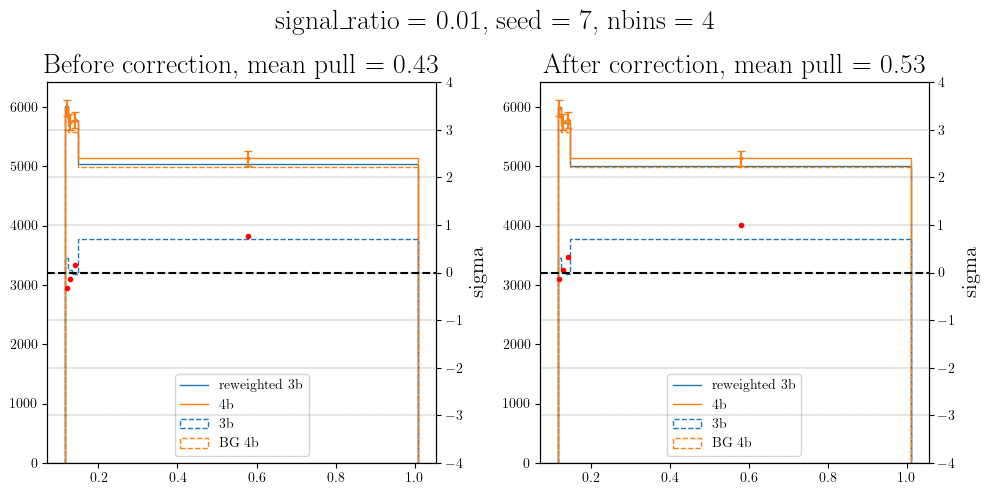

 80%|████████  | 8/10 [00:55<00:13,  6.90s/it]

intercept = 0.07983233779668808, slope = 0


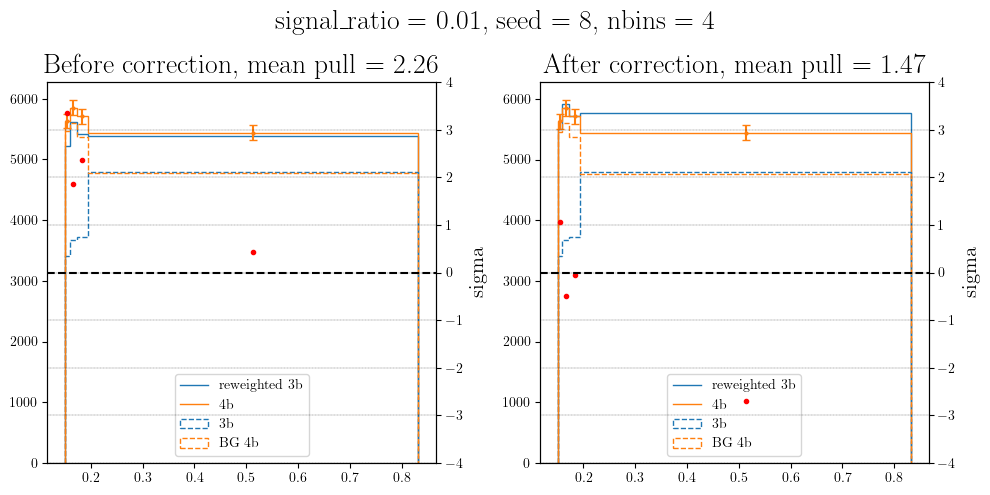

 90%|█████████ | 9/10 [01:02<00:06,  6.90s/it]

intercept = -0.03239259123802185, slope = 0


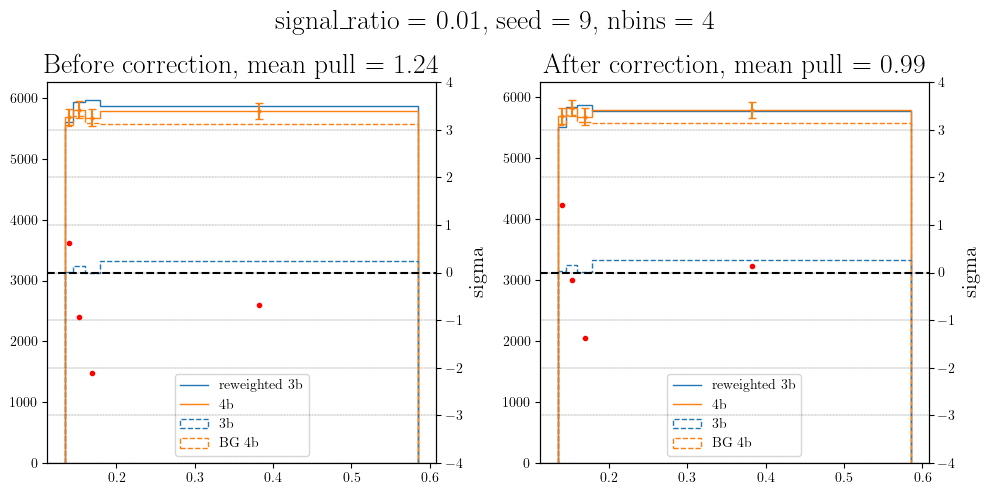

  0%|          | 0/10 [00:00<?, ?it/s]

intercept = 0.1, slope = 0


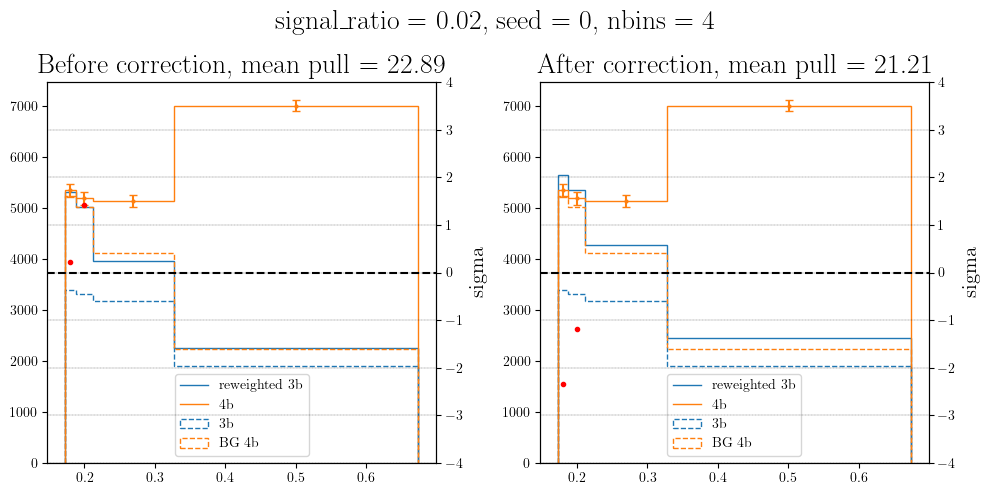

 10%|█         | 1/10 [00:07<01:04,  7.16s/it]

intercept = 0.1, slope = 0


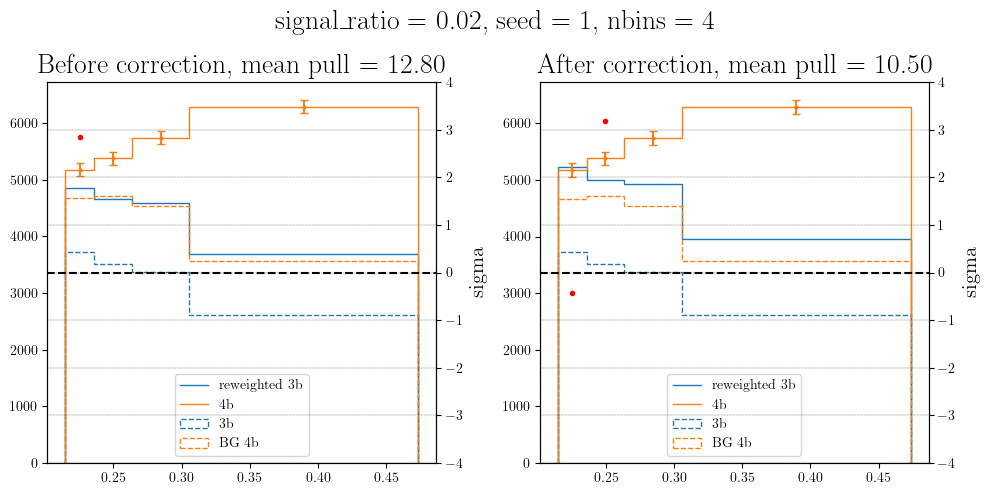

 20%|██        | 2/10 [00:14<00:56,  7.10s/it]

intercept = 0.1, slope = 0


In [5]:
from correct_systematic_error import constrained_linear_fit, get_histograms
from events_data import get_is_signal
from signal_region import get_SR_CR_cut

slope_min = -0.0
slope_max = 0.0
intercept_min = -0.1
intercept_max = 0.1
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_v2"
n_3b = 100_0000

seeds = np.arange(10)
nbins_list = [2**i for i in range(2, 3)]

for signal_ratio in [0.0, 0.01, 0.02]:
    for seed in tqdm.tqdm(seeds):
        hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 3, 
            "model": "FvTClassifier"
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 1
        
        CR_fvt_tinfo = TrainingInfo.load(hashes[0])
        base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
        base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
        smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
        smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

        base_fvt_model = base_fvt_tinfo.load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        base_fvt_model.eval()
        base_fvt_model.to(torch.device("cuda"))
        base_fvt_model: FvTClassifier

        smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        smeared_fvt_model.eval()
        smeared_fvt_model.to(torch.device("cuda"))
        smeared_fvt_model: AttentionClassifier

        # Use the same mother samples and exclude ones used for training base & smeared FvT model
        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
        df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
        events_train = EventsData.from_dataframe(df_train, features)
        df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
        events_tst = EventsData.from_dataframe(df_tst, features)
        # gamma_base, gamma_smeared, q_repr_tst = get_DRs(events_tst, base_fvt_model, smeared_fvt_model, return_repr=True)
        # # SR_stats = np.log(gamma_base / gamma_smeared)
        # q_repr_tst, _ = base_fvt_model.representations(events_tst.X_torch)
        SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
        SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]

        SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])
        
        SR_idx = (SR_stats >= SR_cut)
        CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)
        
        events_tst_SR = events_tst[SR_idx]
        events_tst_CR = events_tst[CR_idx]
        
        SR_stats_SR = SR_stats[SR_idx]
        SR_stats_CR = SR_stats[CR_idx]
        
        CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
        CR_fvt_model.eval()
        CR_fvt_model.to(torch.device("cuda"))
        
        CR_fvt_model: FvTClassifier
        CR_fvt_scores = CR_fvt_model.predict(events_tst.X_torch)[:, 1].detach().cpu().numpy()
                
        fvt_scores_SR = CR_fvt_scores[SR_idx]
        reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
        reweights_SR = np.where(events_tst_SR.is_4b, 1, reweights_SR)
        
        train_size = int(0.2 * len(events_tst_SR))
        train_idx = np.array([True] * train_size + [False] * (len(events_tst_SR) - train_size))
        np.random.seed(0)
        np.random.shuffle(train_idx)
        
        events_tst_SR_train = events_tst_SR[train_idx]
        SR_stats_SR_train = SR_stats_SR[train_idx]
        reweights_SR_train = reweights_SR[train_idx]
        events_tst_SR_test = events_tst_SR[~train_idx]
        SR_stats_SR_test = SR_stats_SR[~train_idx]
        reweights_SR_test = reweights_SR[~train_idx]
        
        for nbins in nbins_list:
            SR_bins = np.quantile(SR_stats_SR_train, np.linspace(0, 1, nbins + 1))
            
            hists_train = get_histograms(events_tst_SR_train, SR_stats_SR_train, SR_bins, reweights_SR_train)
            hists_test = get_histograms(events_tst_SR_test, SR_stats_SR_test, SR_bins, reweights_SR_test)
            
            y = hists_train["4b"] - hists_train["3b_rw"]
            X = np.stack([hists_train["3b"], hists_train["3b_x"]], axis=1)
            V = np.diag(hists_train["3b_sq"] + hists_test["4b_sq"])

            if nbins > 1:
                intercept, slope = constrained_linear_fit(X, y, V,
                                                        beta_0_min=intercept_min, beta_0_max=intercept_max,
                                                        beta_1_min=slope_min, beta_1_max=slope_max)
            else:
                intercept, slope = constrained_linear_fit(X, y, V,
                                                        beta_0_min=intercept_min, beta_0_max=intercept_max,
                                                        beta_1_min=0, beta_1_max=0)
            
            print(f"intercept = {intercept}, slope = {slope}")
            
            test_is_3b = events_tst_SR_test.is_3b

            corrected_reweights = (
                reweights_SR[~train_idx] + intercept + slope * SR_stats_SR_test
            )
            corrected_weights = (
                np.where(events_tst_SR_test.is_4b, 1, corrected_reweights)
                * events_tst_SR_test.weights
            )

            test_is_3b = events_tst_SR_test.is_3b
            hist_3b_corrected = np.histogram(
                SR_stats_SR_test[test_is_3b],
                bins=SR_bins,
                weights=corrected_weights[test_is_3b],
            )[0]
            hist_3b_corrected_sq = np.histogram(
                SR_stats_SR_test[test_is_3b],
                bins=SR_bins,
                weights=corrected_weights[test_is_3b] ** 2,
            )[0]
            hists_test["3b_corrected"] = hist_3b_corrected
            hists_test["3b_corrected_sq"] = hist_3b_corrected_sq
            
            diff_orig = hists_test["4b"] - hists_test["3b_rw"]
            var_orig = hists_test["3b_sq"] + hists_test["4b_sq"]
            
            diff_corrected = hists_test["4b"] - hists_test["3b_corrected"]
            var_corrected = hists_test["3b_corrected_sq"] + hists_test["4b_sq"]

            mean_pull_orig = np.sqrt(np.mean(diff_orig**2 / var_orig))
            mean_pull_corrected = np.sqrt(np.mean(diff_corrected**2 / var_corrected))

            new_weights = events_tst_SR_test.weights.copy()
            new_weights[events_tst_SR_test.is_3b] = new_weights[events_tst_SR_test.is_3b] * (
                reweights_SR_test[events_tst_SR_test.is_3b] + intercept + slope * SR_stats_SR_test[events_tst_SR_test.is_3b])

            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            fig.suptitle(f"signal_ratio = {signal_ratio}, seed = {seed}, nbins = {nbins}")
            ax[0].set_title(f"Before correction, mean pull = {mean_pull_orig:.2f}")
            ax[1].set_title(f"After correction, mean pull = {mean_pull_corrected:.2f}")
            plot_samples_raw(events_tst_SR_test.is_4b, reweights_SR_test * events_tst_SR_test.weights, SR_stats_SR_test, ax[0], bins=SR_bins)
            ax[0].hist(SR_stats_SR_test[events_tst_SR_test.is_3b], bins=SR_bins, weights=events_tst_SR_test.weights[events_tst_SR_test.is_3b], 
                       histtype="step", label="3b", linestyle="--")
            ax[0].hist(SR_stats_SR_test[events_tst_SR_test.is_bg4b], bins=SR_bins, weights=events_tst_SR_test.weights[events_tst_SR_test.is_bg4b], 
                       histtype="step", label="BG 4b", linestyle="--")
            ax[0].legend()
            plot_samples_raw(events_tst_SR_test.is_4b, new_weights, SR_stats_SR_test, ax[1], bins=SR_bins)
            ax[1].hist(SR_stats_SR_test[events_tst_SR_test.is_3b], bins=SR_bins, weights=events_tst_SR_test.weights[events_tst_SR_test.is_3b], 
                       histtype="step", label="3b", linestyle="--")
            ax[1].hist(SR_stats_SR_test[events_tst_SR_test.is_bg4b], bins=SR_bins, weights=events_tst_SR_test.weights[events_tst_SR_test.is_bg4b], 
                       histtype="step", label="BG 4b", linestyle="--")
            ax[1].legend()
            plt.tight_layout()
            plt.show()

In [29]:
import pickle
from itertools import product
from scipy import stats
import matplotlib.pyplot as plt

pull_arrays_dict = pickle.load(open("./data/tmp/pull_arrays_dict.pkl", "rb"))

sig_level = 0.05

pull_arrays = pull_arrays_dict[(-0.0, 0.0, -0.1, 0.1)]
for nbins, signal_ratio in product(nbins_list, [0.0, 0.01, 0.02]):
    print(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
    chi2_stat = np.sqrt(np.mean(pull_arrays[(signal_ratio, nbins)]**2, axis=1))
    z_rej = stats.chi2.ppf(1 - sig_level, df=nbins)
    z_rej = np.sqrt(z_rej / nbins)
    print(np.mean(chi2_stat > z_rej))

signal_ratio = 0.0, nbins = 4
0.04
signal_ratio = 0.01, nbins = 4
0.44
signal_ratio = 0.02, nbins = 4
0.48


In [8]:
import pickle
import scipy.stats as stats
from itertools import product

hist_list = pickle.load(open("./data/tmp/hist_list_v3.pkl", "rb"))

In [63]:
intercept_min = -0.05
intercept_max = 0.05
slope_min = -0.2
slope_max = 0.2

mode = "quantile"
learning_mode = "orig"
model = "AttentionClassifier" if learning_mode == "repr" else "FvTClassifier"

nbins_list = [2**i for i in range(1, 8)]
hashes = np.unique([v["hash"] for v in hist_list if v["model"] == model])
pull_arrays = {(nbins, signal_ratio): [] for nbins, signal_ratio in product(nbins_list, [0.0, 0.01, 0.02])}

for hash in tqdm.tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash)
    smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
    smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
    
    SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
    SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
    
    msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
    train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
    tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
    
    df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
    events_train = EventsData.from_dataframe(df_train, features)
    
    df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, 
                                CR_fvt_tinfo.hparams["signal_region"])
    
    SR_idx = (SR_stats_tst >= SR_cut)    
    events_tst_SR = events_tst[SR_idx]
    SR_stats_SR = SR_stats_tst[SR_idx]
    
    for nbins, signal_ratio in product(nbins_list, [0.0, 0.01, 0.02]):            
        # find v in hist_list that matches the current condition
        vs = [v for v in hist_list if (v["mode"] == mode and
                                        v["nbins"] == nbins and
                                        v["model"] == model and
                                        v["signal_ratio"] == signal_ratio and
                                        v["hash"] == hash)]
        if len(vs) == 0:
            continue
        assert len(vs) == 1
        v = vs[0]
        
        hist_3b = v["3b_SR"]
        hist_4b = v["bg4b_SR"] + v["signal_SR"]
        hist_diff = v["diff_SR"]
        hist_sq = v["sq_SR"]
        bins_SR = v["bins_SR"]
        hist_3b_SRstats = np.histogram(SR_stats_SR[events_tst_SR.is_3b], bins=bins_SR, 
                                    weights=(events_tst_SR.weights * SR_stats_SR)[events_tst_SR.is_3b])[0]
        
        y = hist_diff
        X = np.stack([hist_3b, hist_3b_SRstats], axis=1)
        V = np.diag(hist_sq)

        if nbins > 1:
            intercept, slope = constrained_linear_fit(X, y, V,
                                                    beta_0_min=intercept_min, beta_0_max=intercept_max,
                                                    beta_1_min=slope_min, beta_1_max=slope_max)
        else:
            intercept, slope = constrained_linear_fit(X, y, V,
                                                    beta_0_min=intercept_min, beta_0_max=intercept_max,
                                                    beta_1_min=0, beta_1_max=0)
            
        hist_correction = np.histogram(SR_stats_SR[events_tst_SR.is_3b], 
                                    weights=(events_tst_SR.weights * (intercept + slope * SR_stats_SR))[events_tst_SR.is_3b], 
                                    bins=bins_SR)[0]
        
        pull_SR = (hist_diff - hist_correction) / np.sqrt(hist_sq)
        pull_arrays[(nbins, signal_ratio)].append(pull_SR)  
pull_arrays = {k: np.array(v) for k, v in pull_arrays.items()}


  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [03:03<00:00,  1.22s/it]


signal_ratio = 0.0, nbins = 4
0.04
signal_ratio = 0.01, nbins = 4
0.44
signal_ratio = 0.02, nbins = 4
0.48


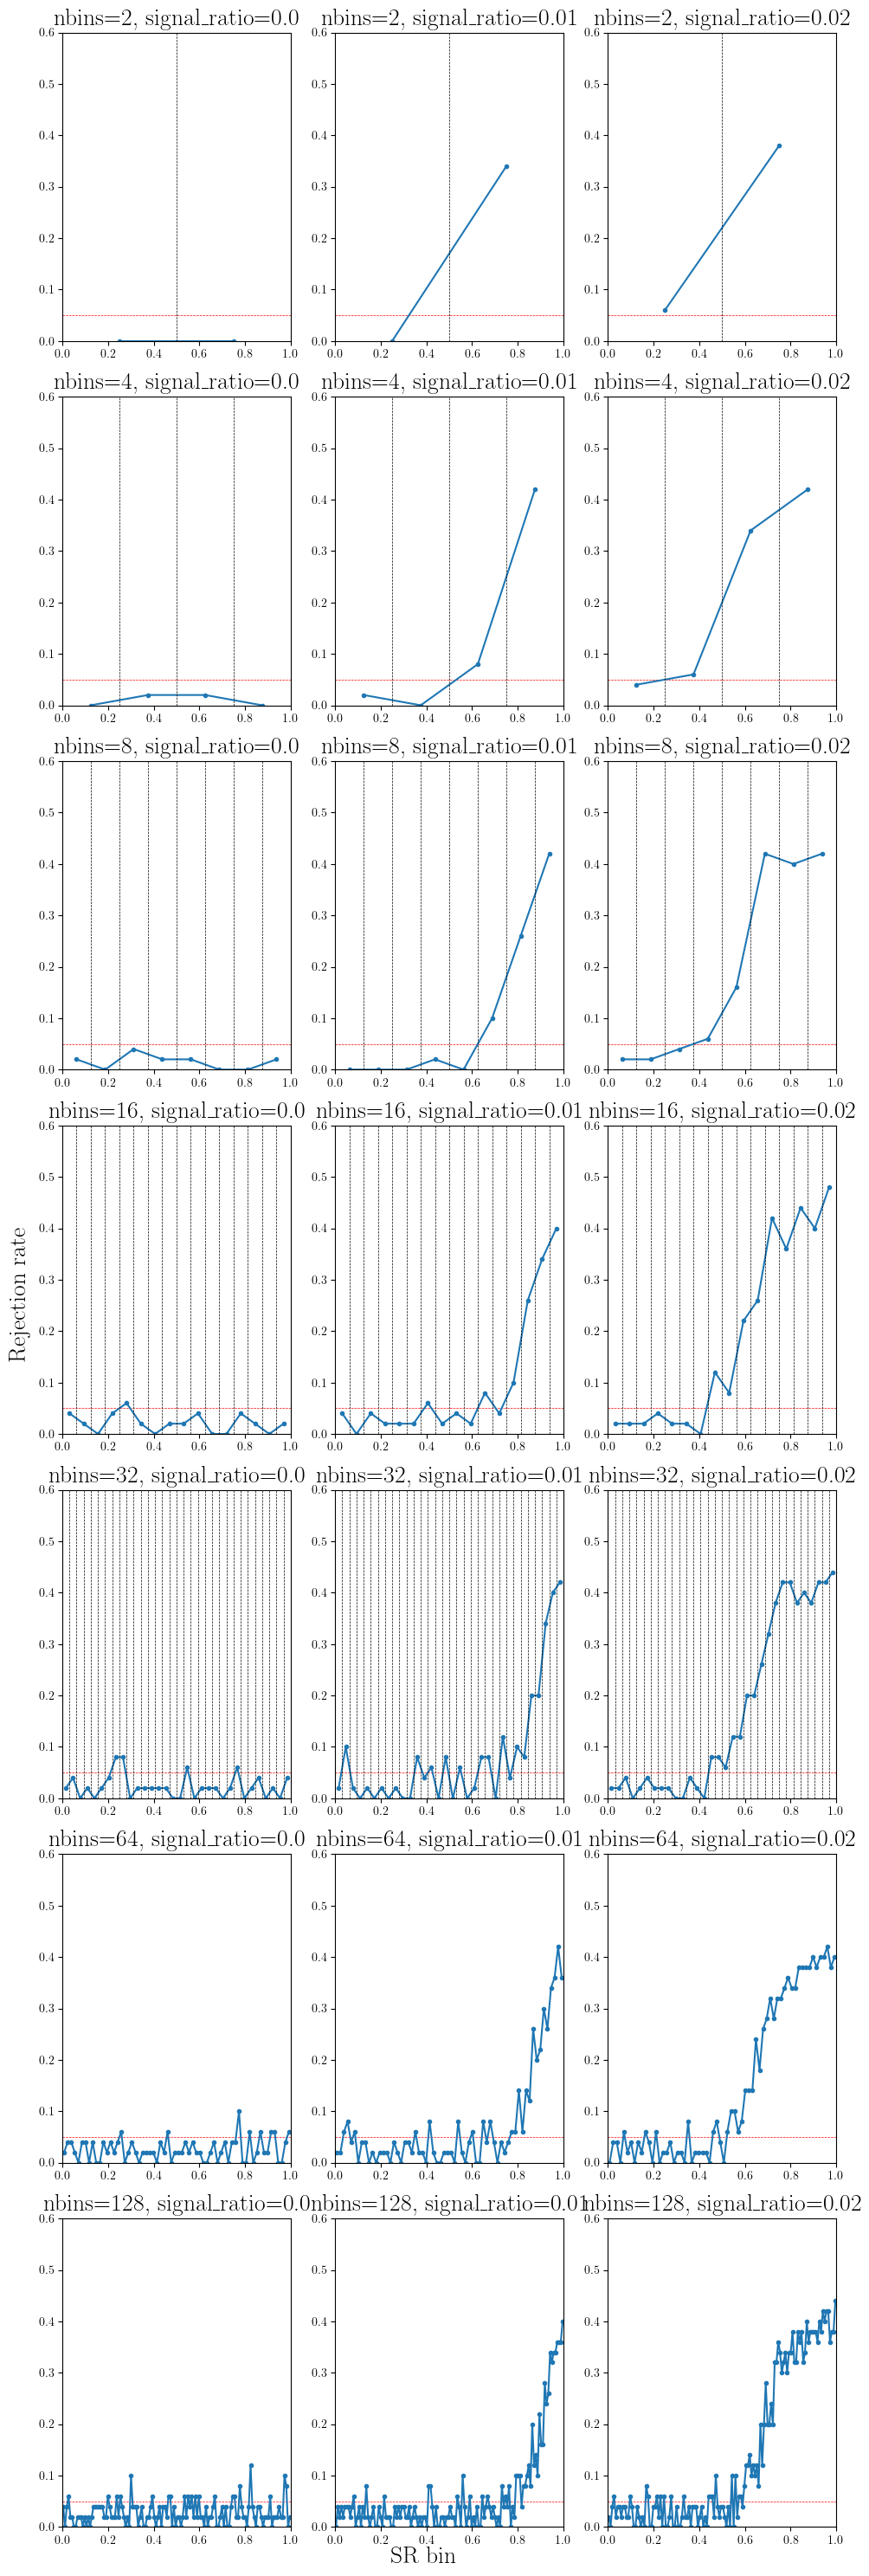

In [69]:
sig_level = 0.05
z_rej = stats.norm.ppf(1 - sig_level / 2)
fig, ax = plt.subplots(nrows=len(nbins_list), ncols=3, figsize=(10, 30))
fig.supxlabel("SR bin")
fig.supylabel("Rejection rate")
for a in ax.flatten():
    a.set_xlim(0, 1)
    a.set_ylim(0, 0.6)
    a.axhline(sig_level, color="red", linestyle="--", linewidth=0.5)
for i, (nbins, signal_ratio) in enumerate(product(nbins_list, [0.0, 0.01, 0.02])):
    current_ax = ax[i // 3, i % 3]
    current_ax.plot((np.arange(nbins) + 1 / 2) / nbins, np.mean(pull_arrays[(nbins, signal_ratio)] > z_rej, axis=0), "o-")
    current_ax.set_title(f"nbins={nbins}, signal_ratio={signal_ratio}")
    if nbins < 2**6:
        for pos in np.arange(nbins + 1) / nbins:
            current_ax.axvline(pos, color="black", linestyle="--", linewidth=0.5)
        
plt.tight_layout()
plt.show()